In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('flights.csv')

#Findout number of total null data
df.isnull().sum()

#Cleaning
df_cleaned=df.dropna(subset=['dep_time','dep_delay','arr_delay','tailnum','air_time','name'])

In [6]:
df_cleaned=df_cleaned.copy()
df_cleaned.loc[:,'is_delayed']=(df_cleaned['arr_delay']>15).astype(int) #new column to identify which flight is delayed.

In [7]:
#Factorize object or any non-int types to int
df_cleaned['origin_encoded']=pd.factorize(df_cleaned['origin'])[0]
df_cleaned['dest_encoded']=pd.factorize(df_cleaned['dest'])[0]
df_cleaned['name_encoded']=pd.factorize(df_cleaned['name'])[0]

x=df_cleaned[['year','month','day','dep_time','sched_dep_time','origin_encoded','dest_encoded','air_time','distance','hour','name_encoded']]
y=df_cleaned['is_delayed']

#Normalize data
sc=StandardScaler()
sc.fit_transform(x,y)

#Split test and train 
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2, random_state=42)

In [12]:
#Import model
rf=RandomForestClassifier()

#Train model
rf.fit(x_train, y_train)

#Prediction
y_hat=rf.predict(x_test)

In [13]:
#Metrics and scoring
accuracy=accuracy_score(y_hat,y_test)
print('accuracy_score:', accuracy)

accuracy_score: 0.9079272949442493


In [14]:
rs=recall_score(y_test, y_hat)
print('Recall_score:', rs)

Recall_score: 0.6819984646878199


In [15]:
ps=precision_score(y_test, y_hat)
print('precision_score:', ps)

precision_score: 0.9097968936678614


Text(50.722222222222214, 0.5, 'prediction')

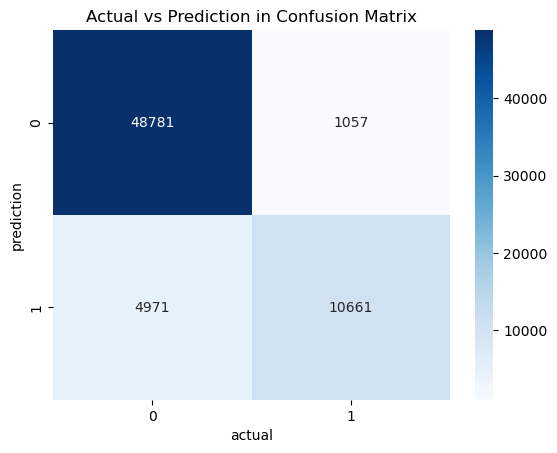

In [16]:
cm= confusion_matrix(y_test, y_hat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Actual vs Prediction in Confusion Matrix')
plt.xlabel('actual')
plt.ylabel('prediction')

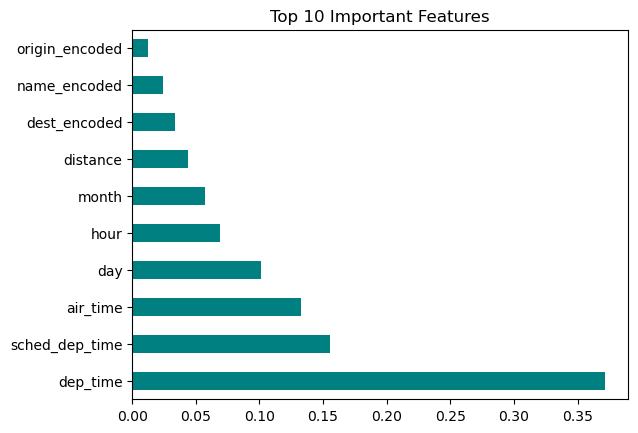

In [17]:
importances = pd.Series(rf.feature_importances_, index=x.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Important Features')
plt.show()

In [18]:
import joblib
joblib.dump(rf, 'rf.joblib', compress=3)

['rf.joblib']